In [62]:
import numpy as np
import matplotlib.pyplot as plt

## Problem 1

#### Part (a)

In [63]:
def lorenz63(t,state,sigma,rho,beta):
    x,y,z = state
    x_dot = sigma*(y - x)
    y_dot = x * (rho - z) - y
    z_dot = x*y-beta*z
    state = np.array([x_dot,y_dot,z_dot])
    return state

def lorenz96(t, u, K, F, d):
    du = np.zeros(K)
    for k in range(K):
        km1 = (k-1) % K
        km2 = (k-2) % K
        kp1 = (k+1) % K
        
        du[k] = u[km1] * (u[kp1] - u[km2]) - d*u[k] + F
        
    return du

def lorenz96two(t,entries,K,F,d,gamma_j,ds,J):
    u = entries[:K]
    v = entries[K:].reshape((K,J))
    du = np.zeros(K)
    dv = np.zeros((K,J))      
    
    for k in range(K):
        km1 = (k-1) % K
        km2 = (k-2) % K
        kp1 = (k+1) % K
        sum_term = 0
        for j in range(J):
            sum_term += gamma_j * v[k,j] * u[k]
            dv[k,j] = -ds[j]*v[k,j] - gamma_j*u[k]**2
            
        du[k] = u[km1] * (u[kp1] - u[km2]) + sum_term - d*u[k] + F 
    
    return np.concatenate((du,dv.flatten()))
    
    

In [64]:
def sturis(t,states,Vp,Vi,Vg,E,tp,ti,td,
           Rm,a1,C1,C2,C3,C4,C5,
           Ub,U0,Um,Rg,alpha,beta):
    Ip,Ii,G,h1,h2,h3 = states
    
    def f1(G,Rm,Vg,C1,a1):
        return Rm / (1 + np.exp(-G/(Vg*C1)+a1))
    def f2(G,Ub,C2,Vg):
        return Ub*(1-np.exp(-G/(C2*Vg)))
    def f3(Ii,C3,Vg,U0,Um,beta,C4,Vi,E,ti):
        kappa = (1/C4)*(1/Vi + 1/(E*ti))
        return (1/(C3*Vg))*(U0 + (Um-U0)/(1+(kappa*Ii)**(-beta)))
    def f4(h3,Rg,alpha,C5,Vp):
        return Rg/(1+np.exp(alpha*(h3/(C5*Vp)-1)))
    
    Ip_dot = f1(G,Rm,Vg,C1,a1) - E * (Ip/Vp - Ii/Vi) - Ip/tp
    
    Ii_dot = E*(Ip/Vp - Ii/Vi)-(Ii/ti)
    
    G_dot = f4(h3,Rg,alpha,C5,Vp) + 0 - f2(G,Ub,C2,Vg) - f3(Ii,C3,Vg,U0,Um,beta,C4,Vi,E,ti)*G
    
    h1_dot = (Ip-h1)/td
    h2_dot = (h1-h2)/td
    h3_dot = (h2-h3)/td
    
    return np.array([
    Ip_dot,
    Ii_dot,
    G_dot,
    h1_dot,
    h2_dot,
    h3_dot
    ])
        

In [65]:
def goodwin(t,state,alpha,beta,delta,upsilon,r,phi0,phi1,kappa0,kappa1,kappa2):
    x1,x2,x3 = state
    def Phi(x2,phi1,phi0):
        return phi1/((1-x2)**2) - phi0
    def Kappa(x1,x3,kappa0,kappa1,kappa2,r):
        return kappa0 + kappa1 * np.exp(kappa2*(1-x1-r*x3))
    
    
    Kappa_val = Kappa(x1,x3,kappa0,kappa1,kappa2,r)
    x1_dot = x1*(Phi(x2,phi1,phi0)-alpha)
    x2_dot = x2*(Kappa_val/upsilon - alpha - beta - delta)
    x3_dot = x3*(r-Kappa_val/upsilon + delta)+Kappa_val-(1-x1)
    
    return np.array([x1_dot,x2_dot,x3_dot])
    

#### Part (b)

In [66]:
def euler_maruyama(rhs,X0,t0,tf,dt,q,args=(),seed=None):
    rng = np.random.default_rng(seed)
    T = int((tf-t0)/dt)
    t = np.zeros(T+1)
    X = np.zeros((T+1,len(X0)))
    
    t[0] = t0
    X[0] = X0
    
    for n in range(T):
        t[n+1] = t[n] + dt #advance the time
        noise = q * np.sqrt(dt) * rng.normal(size=X[n].shape) # create the noise
        X[n+1] = X[n] + dt * rhs(t[n],X[n],*args) + noise
        
    return t,X
        

#### Part (c)

Lorenz 63

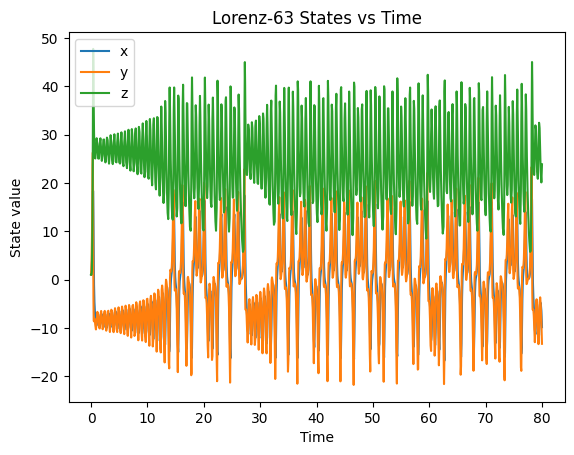

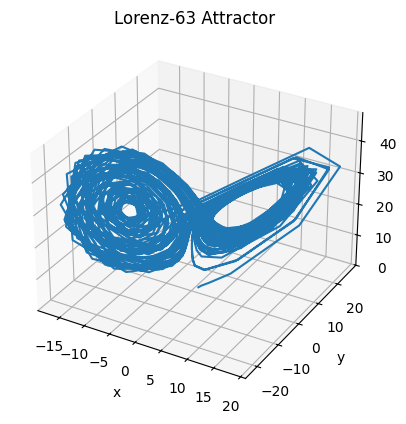

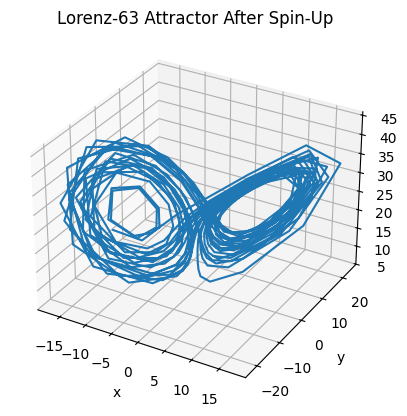

In [67]:
from scipy.integrate import solve_ivp

sigma = 10
rho = 28
beta = float(8/3)

x0 = np.array([1,1,1])
t_span = (0,80)

sol = solve_ivp(
    lorenz63,
    t_span,
    x0,
    args=(sigma,rho,beta)
)

final_state = sol.y[:,-1]

# State component comparison
plt.figure()
plt.plot(sol.t, sol.y[0], label='x')
plt.plot(sol.t, sol.y[1], label='y')
plt.plot(sol.t, sol.y[2], label='z')

plt.xlabel('Time')
plt.ylabel('State value')
plt.legend()
plt.title('Lorenz-63 States vs Time')

plt.show()

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot(sol.y[0], sol.y[1], sol.y[2])

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title('Lorenz-63 Attractor')

plt.show()

mask = sol.t > 50

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot(
    sol.y[0, mask],
    sol.y[1, mask],
    sol.y[2, mask]
)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title('Lorenz-63 Attractor After Spin-Up')

plt.show()


#### Lorenz-96 Single Layer

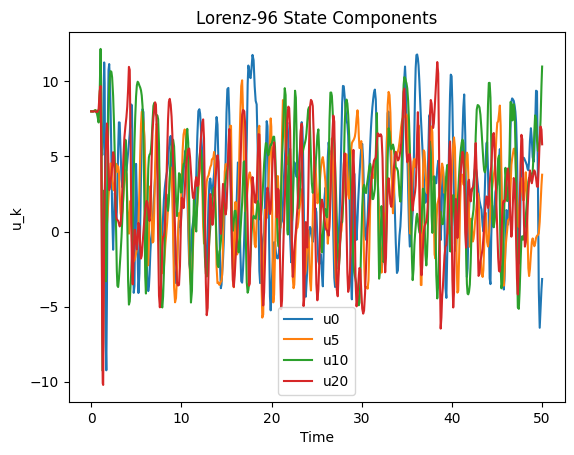

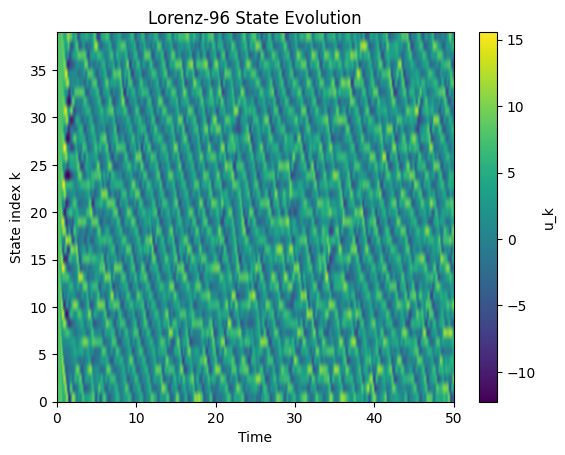

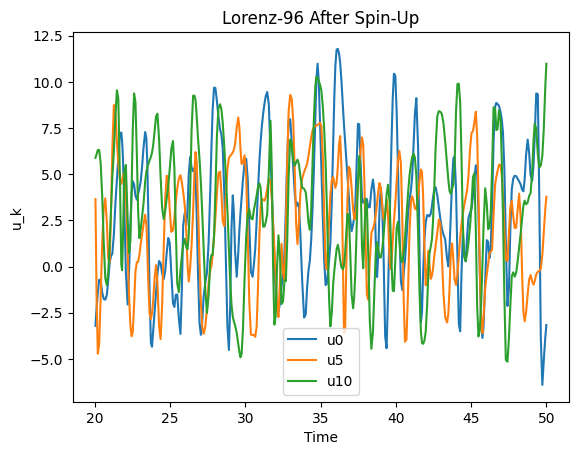

In [68]:
K = 40
F = 8
d = 1

u = F*np.ones(K)
u[0] += 0.01

t_span = (0,50)

sol = solve_ivp(
    lorenz96,
    t_span,
    u,
    args=(K,F,d)
)
final_state = sol.y[:,-1]

plt.figure()

plt.plot(sol.t, sol.y[0], label='u0')
plt.plot(sol.t, sol.y[5], label='u5')
plt.plot(sol.t, sol.y[10], label='u10')
plt.plot(sol.t, sol.y[20], label='u20')

plt.xlabel('Time')
plt.ylabel('u_k')
plt.title('Lorenz-96 State Components')
plt.legend()

plt.show()

plt.figure()

plt.imshow(
    sol.y,
    aspect='auto',
    origin='lower',
    extent=[sol.t[0], sol.t[-1], 0, K-1]
)

plt.xlabel('Time')
plt.ylabel('State index k')
plt.title('Lorenz-96 State Evolution')

plt.colorbar(label='u_k')

plt.show()

mask = sol.t > 20

plt.figure()

plt.plot(sol.t[mask], sol.y[0, mask], label='u0')
plt.plot(sol.t[mask], sol.y[5, mask], label='u5')
plt.plot(sol.t[mask], sol.y[10, mask], label='u10')

plt.xlabel('Time')
plt.ylabel('u_k')
plt.title('Lorenz-96 After Spin-Up')
plt.legend()

plt.show()



#### Two Layer Lorenz-96

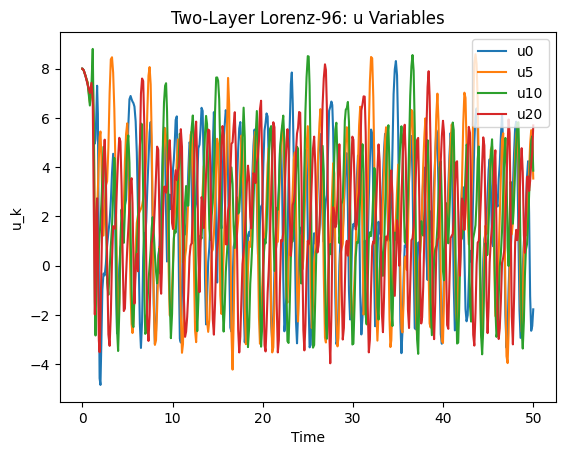

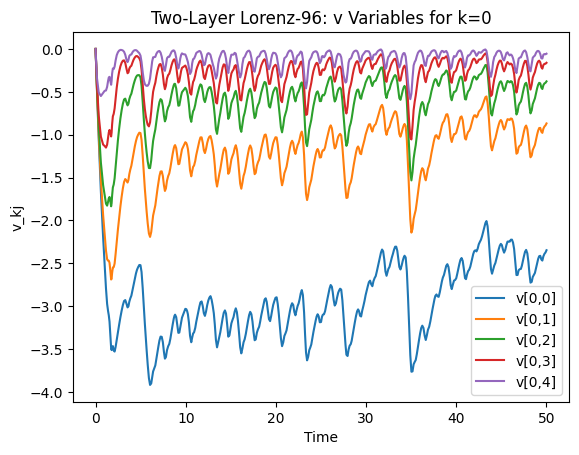

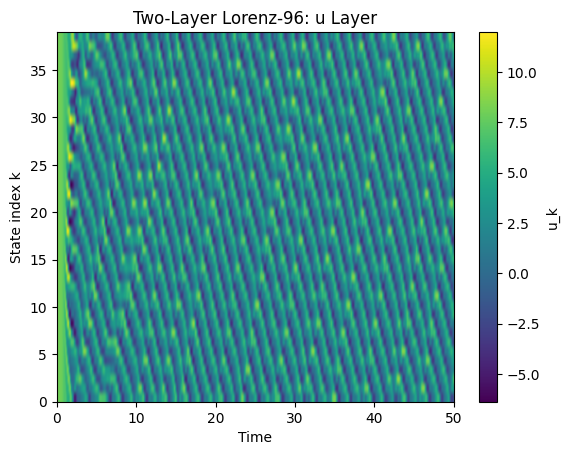

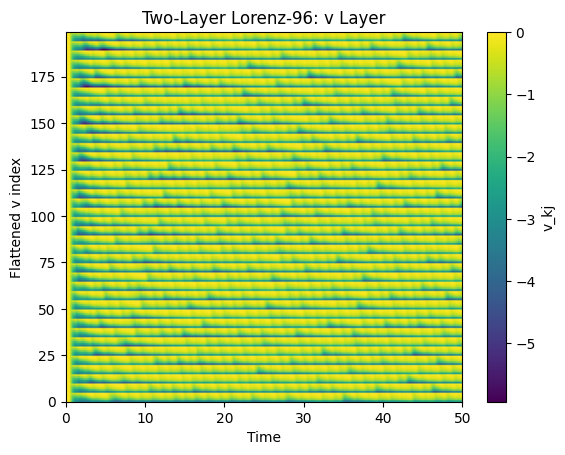

In [69]:
K = 40
J = 5
F = 8
d = 1
gamma_j = 0.05
ds = np.array([0.2,0.5,1,2,5])

u0 = F*np.ones(K)
u0[0] += 0.01

v0 = np.zeros((K,J))

initial_state = np.concatenate((u0,v0.flatten()))

t_span = (0,50)

sol = solve_ivp(lorenz96two,t_span,initial_state,args=(K,F,d,gamma_j,ds,J))
final_state = sol.y[:,-1]

u_sol = sol.y[:K, :]
v_sol = sol.y[K:, :].reshape(K, J, -1)


plt.figure()
plt.plot(sol.t, u_sol[0], label='u0')
plt.plot(sol.t, u_sol[5], label='u5')
plt.plot(sol.t, u_sol[10], label='u10')
plt.plot(sol.t, u_sol[20], label='u20')
plt.xlabel('Time')
plt.ylabel('u_k')
plt.title('Two-Layer Lorenz-96: u Variables')
plt.legend()
plt.show()

plt.figure()
k_plot = 0
for j in range(J):
    plt.plot(sol.t, v_sol[k_plot, j], label=f'v[{k_plot},{j}]')
plt.xlabel('Time')
plt.ylabel('v_kj')
plt.title(f'Two-Layer Lorenz-96: v Variables for k={k_plot}')
plt.legend()
plt.show()

plt.figure()
plt.imshow(
    u_sol,
    aspect='auto',
    origin='lower',
    extent=[sol.t[0], sol.t[-1], 0, K-1]
)
plt.xlabel('Time')
plt.ylabel('State index k')
plt.title('Two-Layer Lorenz-96: u Layer')
plt.colorbar(label='u_k')
plt.show()

v_flat = sol.y[K:, :]
plt.figure()
plt.imshow(
    v_flat,
    aspect='auto',
    origin='lower',
    extent=[sol.t[0], sol.t[-1], 0, K*J-1]
)
plt.xlabel('Time')
plt.ylabel('Flattened v index')
plt.title('Two-Layer Lorenz-96: v Layer')
plt.colorbar(label='v_kj')
plt.show()

#### Sturis ultradian glucose-insulin

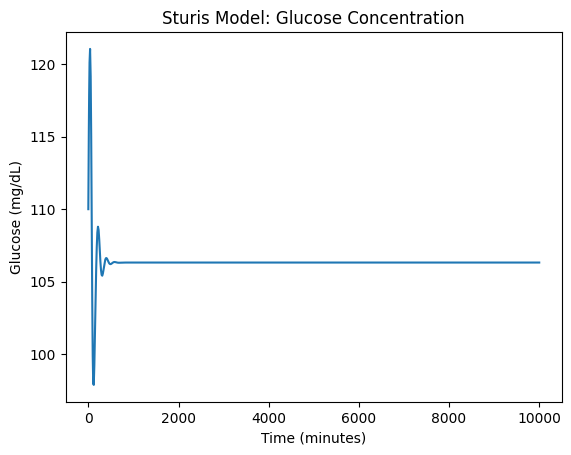

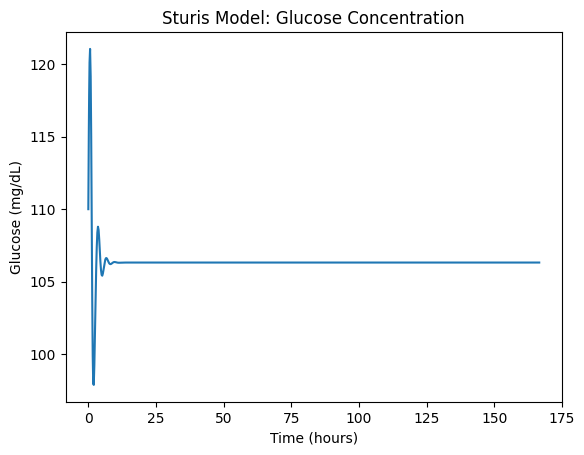

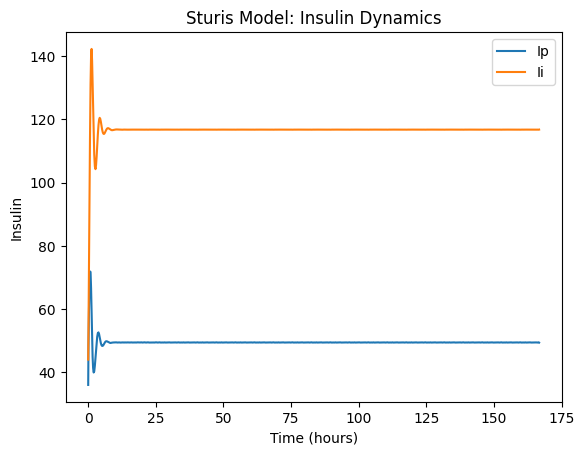

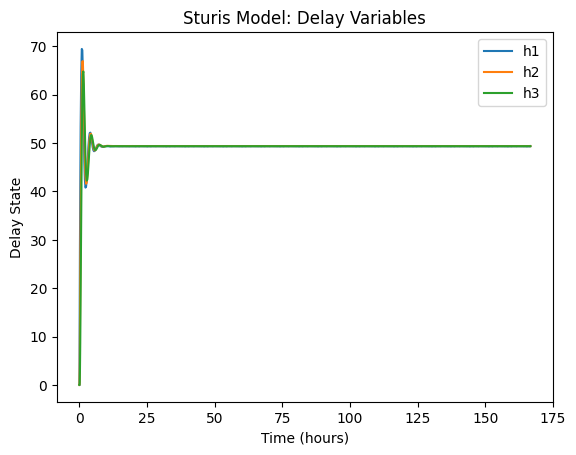

In [70]:
Vp = 3
Vi = 11
Vg = 10
E = 0.2
tp = 6
ti = 100
td = 12

Rm = 209
a1 = 6.6
C1 = 300
C2 = 144
C3 = 100
C4 = 80
C5 = 26

Ub = 72
U0 = 4
Um = 94
Rg = 180
alpha = 7.5
beta = 1.772

state0 = np.array([36, 44, 11000, 0, 0, 0])
t_span = (0, 10000)

sol = solve_ivp(
    sturis,
    t_span,
    state0,
    args=(
        Vp, Vi, Vg, E, tp, ti, td,
        Rm, a1, C1, C2, C3, C4, C5,
        Ub, U0, Um, Rg, alpha, beta
    )
)
final_state = sol.y[:, -1]

glucose_mgdl = sol.y[2] / (10 * Vg)
plt.figure()
plt.plot(sol.t, glucose_mgdl)
plt.xlabel('Time (minutes)')
plt.ylabel('Glucose (mg/dL)')
plt.title('Sturis Model: Glucose Concentration')
plt.show()

time_hours = sol.t / 60
plt.figure()
plt.plot(time_hours, glucose_mgdl)
plt.xlabel('Time (hours)')
plt.ylabel('Glucose (mg/dL)')
plt.title('Sturis Model: Glucose Concentration')
plt.show()

plt.figure()
plt.plot(sol.t / 60, sol.y[0], label='Ip')
plt.plot(sol.t / 60, sol.y[1], label='Ii')
plt.xlabel('Time (hours)')
plt.ylabel('Insulin')
plt.title('Sturis Model: Insulin Dynamics')
plt.legend()
plt.show()

plt.figure()
plt.plot(sol.t / 60, sol.y[3], label='h1')
plt.plot(sol.t / 60, sol.y[4], label='h2')
plt.plot(sol.t / 60, sol.y[5], label='h3')
plt.xlabel('Time (hours)')
plt.ylabel('Delay State')
plt.title('Sturis Model: Delay Variables')
plt.legend()
plt.show()


#### Goodwin-keen economic model

/tmp/ipykernel_33586/56975995.py:6: RuntimeWarning: overflow encountered in exp
  return kappa0 + kappa1 * np.exp(kappa2*(1-x1-r*x3))
/tmp/ipykernel_33586/56975995.py:4: RuntimeWarning: overflow encountered in scalar power
  return phi1/((1-x2)**2) - phi0


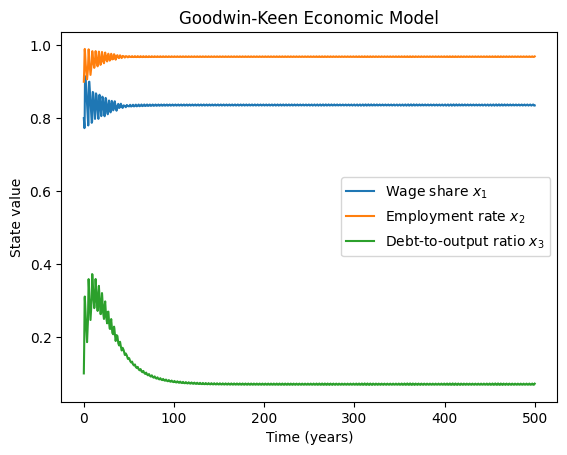

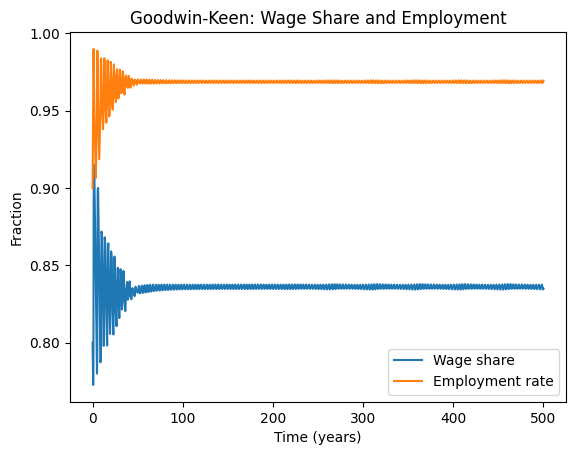

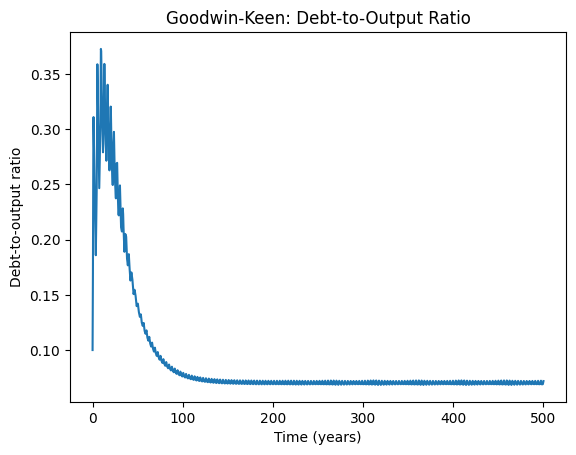

In [71]:
alpha = 0.025
beta = 0.02
delta = 0.01
upsilon = 3
r = 0.03

phi0 = 0.0400641
phi1 = 0.0000641026

kappa0 = -0.0065
kappa1 = np.exp(-5)
kappa2 = 20

state0 = np.array([0.8,0.9,0.1])
t_span = (0,500)

sol = solve_ivp(goodwin,t_span,state0,args=(
        alpha, beta, delta, upsilon, r,
        phi0, phi1,
        kappa0, kappa1, kappa2
    )
)
final_state = sol.y[:,-1]

plt.figure()

plt.plot(sol.t, sol.y[0], label='Wage share $x_1$')
plt.plot(sol.t, sol.y[1], label='Employment rate $x_2$')
plt.plot(sol.t, sol.y[2], label='Debt-to-output ratio $x_3$')

plt.xlabel('Time (years)')
plt.ylabel('State value')
plt.title('Goodwin-Keen Economic Model')
plt.legend()

plt.show()


plt.figure()

plt.plot(sol.t, sol.y[0], label='Wage share')
plt.plot(sol.t, sol.y[1], label='Employment rate')

plt.xlabel('Time (years)')
plt.ylabel('Fraction')
plt.title('Goodwin-Keen: Wage Share and Employment')
plt.legend()

plt.show()

plt.figure()

plt.plot(sol.t, sol.y[2])

plt.xlabel('Time (years)')
plt.ylabel('Debt-to-output ratio')
plt.title('Goodwin-Keen: Debt-to-Output Ratio')

plt.show()


#### Part (d)

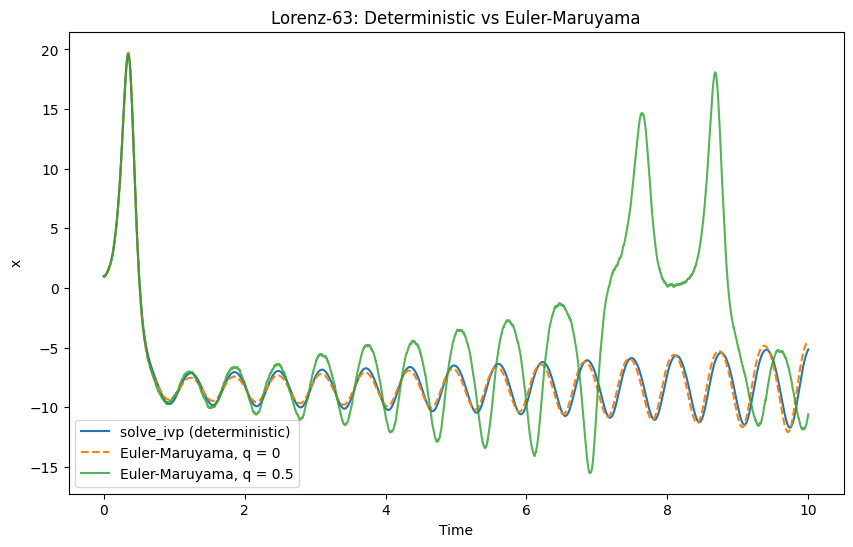

In [78]:
# Deterministic Lorenz63

sigma = 10
rho = 28
beta = 8/3

x0 = np.array([1.0, 1.0, 1.0])

# Use a relatively small timestep for forward Euler / EM
dt = 0.001
t0 = 0
tf = 10

# Change this value to experiment with the noise strength
q_noise = 0.5

# Use the same seed whenever you want the same random realization
seed = 1234

# ---------------------------------------------------
# 1. Deterministic solution using solve_ivp
# ---------------------------------------------------

t_eval = np.arange(t0, tf + dt, dt)

sol = solve_ivp(
    lorenz63,
    (t0, tf),
    x0,
    args=(sigma, rho, beta),
    t_eval=t_eval
)


# ---------------------------------------------------
# 2. Euler-Maruyama with q = 0
#    This should reduce to ordinary forward Euler
# ---------------------------------------------------
t_em0, X_em0 = euler_maruyama(
    lorenz63,
    x0,
    t0,
    tf,
    dt,
    q=0,
    args=(sigma, rho, beta),
    seed=seed
)

# ---------------------------------------------------
# 3. Euler-Maruyama with adjustable q
# ---------------------------------------------------

t_emq, X_emq = euler_maruyama(
    lorenz63,
    x0,
    t0,
    tf,
    dt,
    q=q_noise,
    args=(sigma, rho, beta),
    seed=seed
)

# ---------------------------------------------------
# Plot x(t) for all three cases
# ---------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    sol.t,
    sol.y[0],
    label='solve_ivp (deterministic)'
)

plt.plot(
    t_em0,
    X_em0[:, 0],
    label='Euler-Maruyama, q = 0',
    linestyle='--'
)

plt.plot(
    t_emq,
    X_emq[:, 0],
    label=f'Euler-Maruyama, q = {q_noise}',
    alpha=0.8
)

plt.xlabel('Time')
plt.ylabel('x')
plt.title('Lorenz-63: Deterministic vs Euler-Maruyama')
plt.legend()
plt.show()

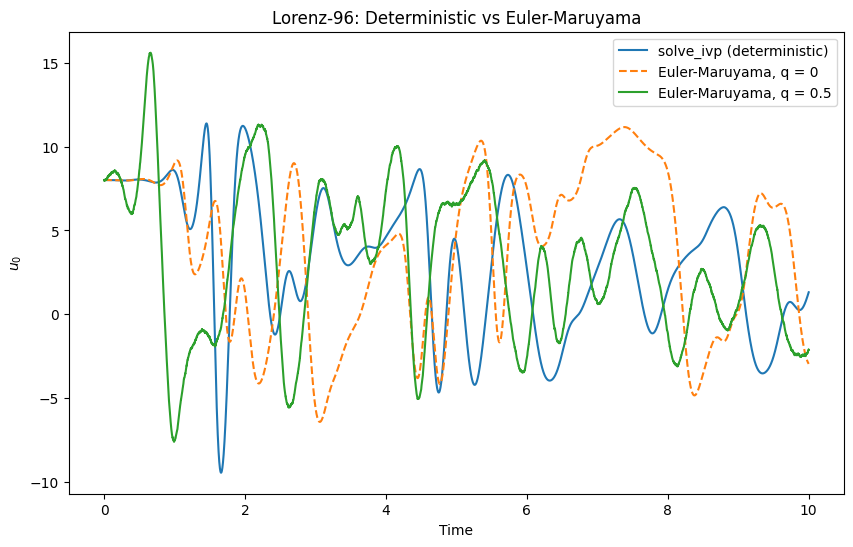

In [83]:
# Parameters
K = 40
F = 8
d = 1

# Initial condition
u0 = F * np.ones(K)
u0[0] += 0.01

# Time settings
t0 = 0
tf = 10
dt = 0.001

# Change this to adjust the stochastic noise
q_noise = 0.5

seed = 1234

# Number of fixed EM steps
number_of_steps = int((tf - t0) / dt)

# Times where solve_ivp will report its solution
t_eval = np.linspace(t0, tf, number_of_steps + 1)


# ------------------------------------------------------------
# 1. Deterministic solve_ivp
# ------------------------------------------------------------

sol = solve_ivp(
    lorenz96,
    (t0, tf),
    u0,
    args=(K, F, d),
    t_eval=t_eval
)


# ------------------------------------------------------------
# 2. Euler-Maruyama with q = 0
# ------------------------------------------------------------

t_em0, U_em0 = euler_maruyama(
    lorenz96,
    u0,
    t0,
    tf,
    dt,
    q=0,
    args=(K, F, d),
    seed=seed
)


# ------------------------------------------------------------
# 3. Euler-Maruyama with adjustable q
# ------------------------------------------------------------

t_emq, U_emq = euler_maruyama(
    lorenz96,
    u0,
    t0,
    tf,
    dt,
    q=q_noise,
    args=(K, F, d),
    seed=seed
)


# ------------------------------------------------------------
# Plot one representative state, u_0
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    sol.t,
    sol.y[0],
    label='solve_ivp (deterministic)'
)

plt.plot(
    t_em0,
    U_em0[:, 0],
    '--',
    label='Euler-Maruyama, q = 0'
)

plt.plot(
    t_emq,
    U_emq[:, 0],
    label=f'Euler-Maruyama, q = {q_noise}'
)

plt.xlabel('Time')
plt.ylabel('$u_0$')
plt.title('Lorenz-96: Deterministic vs Euler-Maruyama')
plt.legend()

plt.show()

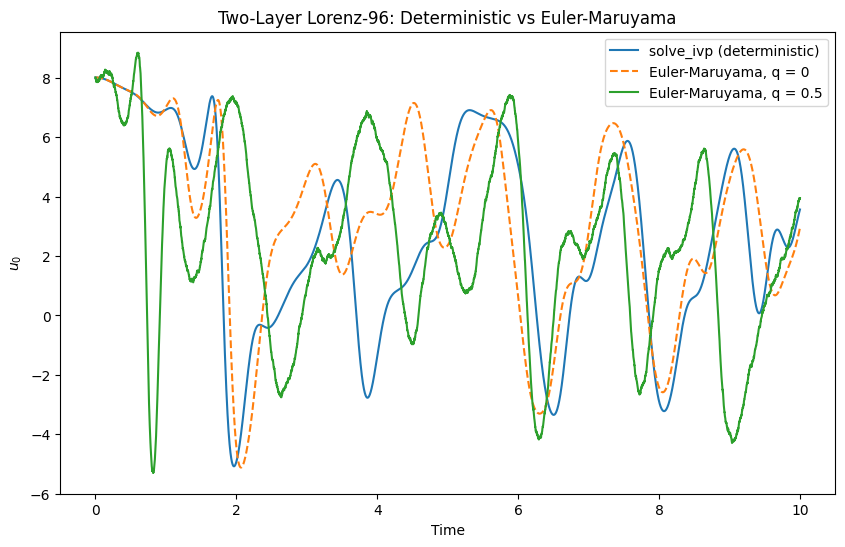

In [81]:
# Parameters
K = 40
J = 5

F = 8
d = 1

gamma_j = 0.05

ds = np.array([0.2, 0.5, 1, 2, 5])


# ------------------------------------------------------------
# Initial conditions
# ------------------------------------------------------------

u0 = F * np.ones(K)
u0[0] += 0.01

v0 = np.zeros((K, J))

# solve_ivp / EM need one long 1D state vector
state0 = np.concatenate((u0, v0.flatten()))


# ------------------------------------------------------------
# Time settings
# ------------------------------------------------------------

t0 = 0
tf = 10
dt = 0.001

# Change this to adjust stochastic noise
q_noise = 0.5

seed = 1234

number_of_steps = int((tf - t0) / dt)

t_eval = np.linspace(t0, tf, number_of_steps + 1)


# ------------------------------------------------------------
# 1. Deterministic solve_ivp
# ------------------------------------------------------------

sol = solve_ivp(
    lorenz96two,
    (t0, tf),
    state0,
    args=(K, F, d, gamma_j, ds, J),
    t_eval=t_eval
)


# ------------------------------------------------------------
# 2. Euler-Maruyama with q = 0
# ------------------------------------------------------------

t_em0, X_em0 = euler_maruyama(
    lorenz96two,
    state0,
    t0,
    tf,
    dt,
    q=0,
    args=(K, F, d, gamma_j, ds, J),
    seed=seed
)


# ------------------------------------------------------------
# 3. Euler-Maruyama with adjustable q
# ------------------------------------------------------------

t_emq, X_emq = euler_maruyama(
    lorenz96two,
    state0,
    t0,
    tf,
    dt,
    q=q_noise,
    args=(K, F, d, gamma_j, ds, J),
    seed=seed
)


# ------------------------------------------------------------
# Plot u_0
#
# Since the first K entries of the state are the u variables,
# index 0 corresponds to u_0.
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    sol.t,
    sol.y[0],
    label='solve_ivp (deterministic)'
)

plt.plot(
    t_em0,
    X_em0[:, 0],
    '--',
    label='Euler-Maruyama, q = 0'
)

plt.plot(
    t_emq,
    X_emq[:, 0],
    label=f'Euler-Maruyama, q = {q_noise}'
)

plt.xlabel('Time')
plt.ylabel('$u_0$')
plt.title('Two-Layer Lorenz-96: Deterministic vs Euler-Maruyama')
plt.legend()

plt.show()